# Refinery Thermodynamics — Milestone 20

Milestone 19 turned a crude assay into a few hundred pseudocomponents and flashed them with a cubic equation of state. That is a legitimate way to simulate a crude tower — but it is not the way a crude tower is *validated*. Refinery practice standardised, decades before cubic EOS were trusted for liquids, on a different set of methods: **Grayson–Streed** and **Braun K10** for K-values, **Lee–Kesler** for enthalpies, a **volume translation** for heavy-liquid density, and the **free-water** approximation for the water that stripping steam puts into every overhead drum and side stripper. Plant data were fitted with those methods, textbook design cases (Watkins, the API *Technical Data Book*) are stated in them, and a simulator that cannot run them cannot be checked against the literature.

Milestone 20 adds all of them, built for the *outer loop* of an inside-out column solver: O(N) per stage for the K-value methods, one O(N²) mixing pass for Lee–Kesler, and nothing allocated inside an iteration. This notebook shows each method, checks it against something independent, and shows it running on the 300-cut assay from Milestone 19.

## Setup (optional)

The cell below is **commented out** — the notebook runs top-to-bottom against whatever `vle-thermo` is already in your kernel. Uncomment it to pull the newest released wheel from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

The thesis is a Chao–Seader program before it is anything else: Reference (4), the Da Silva & Báez Pascal code that the VB6 program grew out of, carries the Chao–Seader liquid-fugacity correlation in `TERMOII.PAS`, and [Chapter II §2.4 — Activity Coefficient Models](../docs/en/research-paper/chapter-2-vle-theory.md#24-activity-coefficient-models) gives the regular-solution theory that supplies its activity coefficient:

> The Scatchard–Hildebrand model expresses the activity coefficient in terms of the solubility parameters and molar volumes of the components...

Two things about that lineage matter here, and Milestone 20 had to face both. First, the coefficient table the legacy code carries under the name "Chao–Seader" is in fact **Grayson & Streed's 1963 refit** — the version every refinery package ships — not Chao & Seader's 1961 original. Second, the legacy K-value used $\nu_i$ alone; the framework is $K_i = \nu_i \gamma_i / \hat\phi_i^V$, with $\gamma_i$ from regular-solution theory. Both are corrected in this milestone (the legacy `chao_seader` path is kept exactly as it was, for compatibility, and documented for what it is).

Everything else in this notebook — Lee–Kesler, Peneloux, Braun K10, free water — is *upstream* of the thesis, in the same sense Milestone 19 was: the paper assumes you have a component list and a model pair; refinery practice supplies both.

## What Milestone 20 built

| need | method | where in the API |
|---|---|---|
| free water from stripping steam | **water-decant flash** — hydrocarbons flash at $P - y_w P$, vapor saturated with water at $P^{sat}_w(T)$, free water by balance | `System.flash_free_water` |
| K-values in hydrogen-rich / heavy service | **Grayson–Streed** $K_i = \nu_i\gamma_i/\hat\phi_i^V$ | `System(..., liquid_model="grayson_streed")` |
| K-values for heavy fractions at low pressure | **Braun K10** — $K_i = P^{MB}_i(T;\,T_{b,i})/P$ from Maxwell–Bonnell, now inverted in **closed form** | `System(..., liquid_model="bk10")` |
| enthalpy / entropy | **Lee–Kesler** three-parameter corresponding states, pure and mixture | `System.lee_kesler_departure`, `System.enthalpy_entropy_lee_kesler` |
| heavy-liquid density | **Peneloux** volume translation of SRK / PR | `System.peneloux_shifts`, `System.translated_density` |

The pure / reduced-state pieces are also exposed on their own in **`vle.refinery`** (`lee_kesler_reduced`, `regular_solution_ln_nu`, `peneloux_shift`), the way `vle.petroleum` exposes its correlations. And the pseudocomponents from Milestone 19 now carry what these methods read: a solubility parameter, the Watson $K$, and a Rackett $Z_{RA}$.

**Two things this milestone deliberately did *not* build**, stated here so nobody has to discover them: the free-water flash is the industry's decant *approximation*, not a general three-liquid stability analysis (it cannot find a second hydrocarbon liquid, and it neglects water dissolved in the oil); and Braun's pressure-correction charts are not implemented — BK10 here is the K10 value scaled Raoult-style, which is what its low-pressure validity range assumes.

## Worked example, part 1 — the same crude, three K-value methods

Start from the Milestone 19 assay — a light sweet crude at 35 °API — and characterize it into 30 cuts. The pseudocomponents come back with everything the refinery methods need.

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vle import System, refinery, steam
from vle.petroleum import Assay
from vle import components as db

assay = Assay(
    fractions   = [0.0, 0.10, 0.30, 0.50, 0.70, 0.90, 0.95],
    temperatures= [310.0, 380.0, 460.0, 540.0, 620.0, 730.0, 790.0],   # K, TBP
    basis       = 'tbp',
    api_gravity = 35.0,
)
comps, z = assay.components(n=30)
c = comps[10]
print(f'{c.name}: Tb = {c.tb:.1f} K, K_W = {c.watson_k:.2f}, '
      f'delta = {c.solubility_param:.2f} (cal/cm3)^1/2, Z_RA = {c.zra:.4f}, M = {c.mw:.1f}')

T, P = 500.0, 200.0                       # K, kPa -- the M19 flash point
methods = {
    'PR (M19)':        System(comps, eos='PR'),
    'Grayson-Streed':  System(comps, eos='RKS', liquid_model='grayson_streed'),
    'Braun K10':       System(comps, vapor_model='ideal', liquid_model='bk10'),
}
results = {name: s.flash_pt(T, P, z) for name, s in methods.items()}
print(f'\nflash at {T} K, {P} kPa')
for name, r in results.items():
    print(f'  {name:<16} beta = {r.beta:.4f}   K spans {min(r.k):.2e} .. {max(r.k):.2f}')

PC-11: Tb = 473.0 K, K_W = 11.55, delta = 7.08 (cal/cm3)^1/2, Z_RA = 0.2539, M = 156.7

flash at 500.0 K, 200.0 kPa
  PR (M19)         beta = 0.4260   K spans 2.08e-04 .. 12.49
  Grayson-Streed   beta = 0.4209   K spans 2.43e-04 .. 12.71
  Braun K10        beta = 0.4499   K spans 7.76e-05 .. 19.53


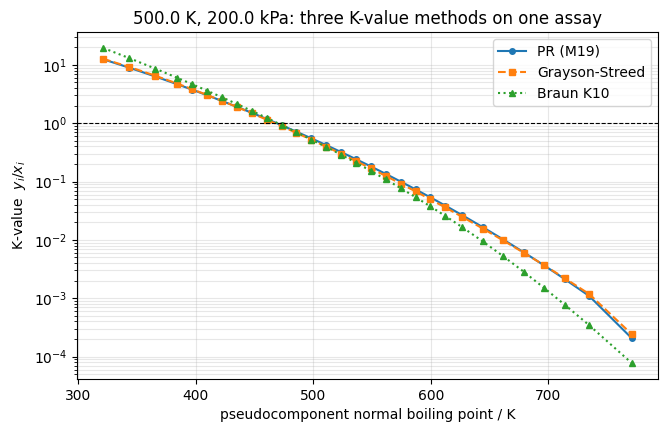

In [3]:
tb = np.array([c.tb for c in comps])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for (name, r), mk in zip(results.items(), ['o-', 's--', '^:']):
    ax.semilogy(tb, r.k, mk, label=name, ms=4)
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_xlabel('pseudocomponent normal boiling point / K')
ax.set_ylabel('K-value  $y_i/x_i$')
ax.set_title(f'{T} K, {P} kPa: three K-value methods on one assay')
ax.grid(alpha=0.3, which='both'); ax.legend()
plt.show()

# Assertion cell: the three methods agree on the physics -- same ordering, same
# cut point to within a couple of pseudocomponents, betas within a few points.
betas = [r.beta for r in results.values()]
assert max(betas) - min(betas) < 0.08, betas
for r in results.values():
    assert all(a > b for a, b in zip(r.k, r.k[1:])), 'K must fall monotonically with Tb'
    assert max(abs(r.beta*r.y[i] + (1-r.beta)*r.x[i] - z[i]) for i in range(len(z))) < 1e-9

Three genuinely different models — a cubic EOS, a regular-solution correlation, and a vapor-pressure chart — put the flash's cut point within a couple of pseudocomponents of each other and the vapor fraction within a few points. That is the level of agreement one should expect between K-value methods that were all fitted to the same hydrocarbon data; the differences are what a refinery engineer tunes against plant data. Where they *would* diverge — hydrogen-rich hydrotreater service for Grayson–Streed, deep-vacuum residue for BK10 — is exactly where each was invented.

The Grayson–Streed line is not just $\nu_i$: the regular-solution $\gamma_i$ is in it, from the solubility parameters the characterization estimated per cut. Check one component by hand.

In [4]:
gs = methods['Grayson-Streed']
r = results['Grayson-Streed']
i = 10
ln_nu  = refinery.regular_solution_ln_nu(T, P, comps[i].tc, comps[i].pc, comps[i].omega)
ln_phi = System(comps, eos='RKS').ln_phi(T, P, r.y, 'vapor')[i]
# Scatchard-Hildebrand: ln gamma_i = V_i (delta_i - delta_bar)^2 / (R T),  R in cal
vl = np.array([c.liquid_volume for c in comps]); dl = np.array([c.solubility_param for c in comps])
x = np.array(r.x)
dbar = (x*vl*dl).sum() / (x*vl).sum()
ln_gamma = vl[i]*(dl[i]-dbar)**2 / (8.31451*0.23898*T)
k_hand = np.exp(ln_nu + ln_gamma - ln_phi)
print(f'{comps[i].name}: ln nu = {ln_nu:+.4f}, ln gamma = {ln_gamma:+.4f}, ln phi_V = {ln_phi:+.4f}')
print(f'  K by hand = {k_hand:.5f}, K from the flash = {r.k[i]:.5f}')
assert abs(k_hand - r.k[i]) < 1e-9 * r.k[i]

PC-11: ln nu = -0.1926, ln gamma = +0.0025, ln phi_V = -0.0731
  K by hand = 0.88951, K from the flash = 0.88951


## Worked example, part 2 — Lee–Kesler enthalpy against the EOS route

An inside-out column solver evaluates rigorous enthalpies once per stage per outer iteration. Lee–Kesler is the refinery-standard way to do that for petroleum fractions, and it costs one O(N²) mixing pass plus two small root solves. Compare it with the PR departure on the assay's liquid across the column's temperature range — and time it at N = 300, because the plan's whole point is that this has to be cheap.

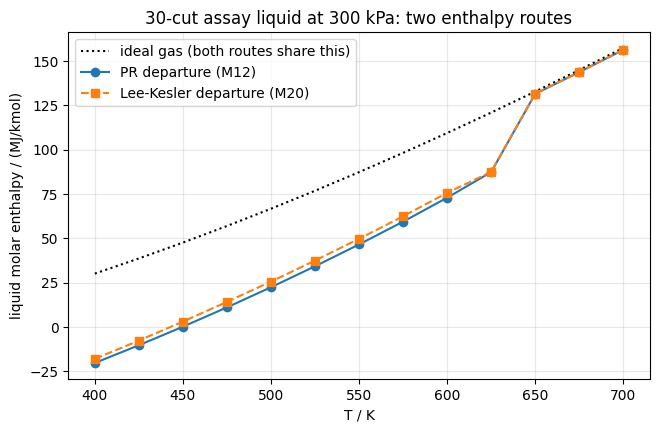

pseudo-critical: Tc = 673.3 K, Pc = 2174 kPa, omega = 0.447
at 500 K: Z = 0.0189, (H-H0)/RT = -9.884, (S-S0)/R = -9.122, ln(f/P) = -0.762


In [5]:
pr = methods['PR (M19)']
Ts = np.linspace(400.0, 700.0, 13)
h_pr = np.array([pr.enthalpy_entropy(t, 300.0, z, 'liquid')[0] for t in Ts])
h_lk = np.array([pr.enthalpy_entropy_lee_kesler(t, 300.0, z, 'liquid')[0] for t in Ts])
h_ig = np.array([System(comps, vapor_model='ideal', liquid_model='ideal')
                 .enthalpy_entropy(t, 300.0, z, 'vapor')[0] for t in Ts])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(Ts, h_ig/1e3, 'k:', label='ideal gas (both routes share this)')
ax.plot(Ts, h_pr/1e3, 'o-', label='PR departure (M12)')
ax.plot(Ts, h_lk/1e3, 's--', label='Lee-Kesler departure (M20)')
ax.set_xlabel('T / K'); ax.set_ylabel('liquid molar enthalpy / (MJ/kmol)')
ax.set_title('30-cut assay liquid at 300 kPa: two enthalpy routes')
ax.grid(alpha=0.3); ax.legend()
plt.show()

d = pr.lee_kesler_departure(500.0, 300.0, z, 'liquid')
tc_m, pc_m, w_m = pr.lee_kesler_pseudocritical(z)
print(f'pseudo-critical: Tc = {tc_m:.1f} K, Pc = {pc_m:.0f} kPa, omega = {w_m:.3f}')
print(f'at 500 K: Z = {d.z:.4f}, (H-H0)/RT = {d.h_dep_rt:.3f}, (S-S0)/R = {d.s_dep_r:.3f}, ln(f/P) = {d.ln_phi:.3f}')

# Assertion cell: both routes sit below the ideal gas by a heat of vaporization
# and agree with each other to a fraction of R*T -- their known level of
# disagreement on hydrocarbon liquids.
R = 8.31451
assert np.all(h_pr < h_ig) and np.all(h_lk < h_ig)
assert np.max(np.abs(h_pr - h_lk)) < 0.6 * R * Ts.max(), np.max(np.abs(h_pr - h_lk))
# Gibbs consistency of the reduced functions: (S-S0)/R = (H-H0)/RT - ln(f/P)
assert abs(d.s_dep_r - (d.h_dep_rt - d.ln_phi)) < 1e-10

In [6]:
# The cost at column scale: 300 pseudocomponents, one mixture enthalpy.
big, zbig = assay.to_system(n=300, eos='PR')
for label, fn in [('Lee-Kesler H, eta=0.25 (N=300)', lambda: big.enthalpy_entropy_lee_kesler(500.0, 200.0, zbig, 'liquid')),
                  ('PR H, EOS departure   (N=300)', lambda: big.enthalpy_entropy(500.0, 200.0, zbig, 'liquid')),
                  ('PR two-phase flash    (N=300)', lambda: big.flash_pt(500.0, 200.0, zbig))]:
    fn()                                       # warm
    t0 = time.perf_counter(); n = 20
    for _ in range(n): fn()
    print(f'{label}: {1e3*(time.perf_counter()-t0)/n:7.3f} ms')
print(f'(the flash is two-phase here: beta = {big.flash_pt(500.0, 200.0, zbig).beta:.3f})')

Lee-Kesler H, eta=0.25 (N=300):   0.094 ms
PR H, EOS departure   (N=300):   0.130 ms
PR two-phase flash    (N=300):   0.045 ms
(the flash is two-phase here: beta = 0.426)


A Lee–Kesler mixture enthalpy at N = 300 costs a tenth of a millisecond, on the same footing as the EOS departure — the O(N²) double sum is forty-five thousand multiplies on precomputed $V_c^{1/3}$ and $\sqrt{T_c}$ (the first draft had a `powf` in that loop and cost 0.31 ms; replacing it with two square roots for $\eta = 0.25$ was a measured 3.4× win), and the two reduced-BWR root solves are fixed cost. Set against a 50-stage column that evaluates it once per stage per outer iteration, the thermodynamics is not what limits an inside-out solve.

## Worked example, part 3 — Peneloux, and what a bare cubic gets wrong

SRK fixes $Z_c = 1/3$ and PR $0.307$; real hydrocarbons sit at 0.25–0.29, and the price is a liquid volume 10–20 % too large for SRK on a heavy cut. Peneloux's constant volume shift $c_i$ fixes it *without touching a single K-value* — the shift cancels identically in $\hat\phi_i^L/\hat\phi_i^V$. Check both claims on the assay.

In [7]:
names = ['n-pentane', 'n-heptane', 'n-decane']
measured = {'n-pentane': 626.0, 'n-heptane': 684.0, 'n-decane': 730.0}    # kg/m3 at 25 degC
print(f"{'':12}{'raw SRK':>10}{'SRK+Peneloux':>14}{'raw PR':>10}{'PR+Peneloux':>13}{'measured':>10}")
for eos in ['RKS', 'PR']:
    pass
rows = {}
for nm in names:
    row = []
    for eos in ['RKS', 'PR']:
        s = System([nm], eos=eos)
        v_raw = s.z_factor(298.15, 101.325, [1.0], 'liquid') * 8.31451 * 298.15 / 101.325 * 1000
        rho_raw = 1000 * s.components[0].mw / v_raw
        rho_tr = s.translated_density(298.15, 101.325, [1.0], 'liquid')
        row += [rho_raw, rho_tr]
    rows[nm] = row
    print(f'{nm:12}{row[0]:10.1f}{row[1]:14.1f}{row[2]:10.1f}{row[3]:13.1f}{measured[nm]:10.1f}')

# Assertion cell: translated SRK lands within 3 % of measured for all three;
# and the flash is unaffected by the shift (it never enters the fugacities).
for nm in names:
    assert abs(rows[nm][1] - measured[nm]) / measured[nm] < 0.03, nm
s = System(['n-heptane', 'n-decane'], eos='RKS')
r_a = s.flash_pt(430.0, 150.0, [0.5, 0.5])
print(f'\nSRK shifts c_i = {s.peneloux_shifts()} cm3/mol; flash beta = {r_a.beta:.6f} (translation does not enter K)')

               raw SRK  SRK+Peneloux    raw PR  PR+Peneloux  measured
n-pentane        566.7         626.9     640.3        612.4     626.0
n-heptane        596.1         691.0     671.3        670.4     684.0
n-decane         597.9         743.1     671.2        721.0     730.0

SRK shifts c_i = [23.07483151973952, 46.50260672406216] cm3/mol; flash beta = 0.603954 (translation does not enter K)


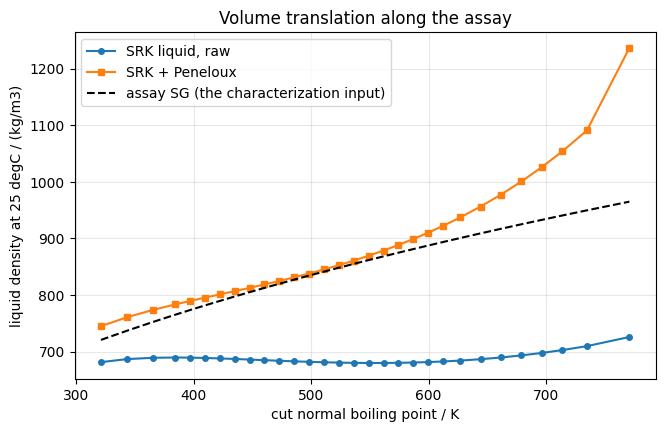

In [8]:
# Along the assay: translated vs raw SRK liquid density per cut, at 25 degC.
srk = System(comps, eos='RKS')
rho_raw, rho_tr, sg_meas = [], [], []
cuts = assay.cuts(n=30)
for i, c in enumerate(comps):
    xi = [0.0]*len(comps); xi[i] = 1.0
    v = srk.z_factor(298.15, 101.325, xi, 'liquid') * 8.31451 * 298.15 / 101.325 * 1000
    rho_raw.append(1000 * c.mw / v)
    rho_tr.append(srk.translated_density(298.15, 101.325, xi, 'liquid'))
    sg_meas.append(999.0 * cuts[i]['sg'])          # the cut's own SG 60/60 as density
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(tb, rho_raw, 'o-', label='SRK liquid, raw', ms=4)
ax.plot(tb, rho_tr, 's-', label='SRK + Peneloux', ms=4)
ax.plot(tb, sg_meas, 'k--', label='assay SG (the characterization input)')
ax.set_xlabel('cut normal boiling point / K'); ax.set_ylabel('liquid density at 25 degC / (kg/m3)')
ax.set_title('Volume translation along the assay')
ax.grid(alpha=0.3); ax.legend()
plt.show()

The dashed line is the density the characterization *started from* — each cut's SG is an input, so it is the closest thing to a measurement here. Raw SRK is systematically light; the translated curve tracks the input across the barrel. (It is not exact: the shift is calibrated at $T_r \approx 0.7$ and the heavy cuts at 25 °C are far below that.)

## Worked example, part 4 — free water in the overhead drum

Add 4 mol% stripping steam to the assay and cool the overhead to reflux-drum conditions. Water's saturation pressure there is a few tens of kPa, the vapor can hold only that much of it, and the rest **must** appear as a second liquid. A two-phase flash has no way to say so; the free-water flash does. Water's $P^{sat}$ is taken from IAPWS-IF97 (`vle.steam`) rather than an Antoine fit — passing it in is a one-liner.

In [9]:
wet = comps + [db.get('water')]
zw  = [zi*0.96 for zi in z] + [0.04]
sys_w = System(wet, eos='PR')

Td, Pd = 320.0, 150.0                        # reflux drum
r = sys_w.flash_free_water(Td, Pd, zw, water='water', psat_water=steam.psat(Td))
print(f'overhead drum at {Td} K, {Pd} kPa  (Psat_w = {r.psat_water:.2f} kPa, y_w = {r.y_water:.4f})')
print(f'  vapor          {r.vapor_fraction:8.4f} mol/mol feed')
print(f'  hydrocarbon L  {r.hc_liquid_fraction:8.4f}')
print(f'  free water     {r.free_water_fraction:8.4f}   <- the decant leg')
print(f'  water in vapor {r.vapor_fraction*r.y[-1]:8.4f}   + free water = {r.vapor_fraction*r.y[-1] + r.free_water_fraction:.4f} = feed water')

# And a hot side stripper: same feed, 560 K -- Psat_w far above P, no free water can exist.
r_hot = sys_w.flash_free_water(560.0, 250.0, zw, water='water', psat_water=steam.psat(560.0))
print(f'\nside stripper at 560 K, 250 kPa: free water = {r_hot.free_water}, '
      f'water all in vapor: {r_hot.vapor_fraction*r_hot.y[-1]:.4f} of feed')

# Assertion cell: balances close in both cases; the drum decants, the stripper does not.
for res in (r, r_hot):
    assert abs(res.vapor_fraction + res.hc_liquid_fraction + res.free_water_fraction - 1.0) < 1e-12
    assert abs(res.vapor_fraction*res.y[-1] + res.free_water_fraction - 0.04) < 1e-10
    for i in range(len(comps)):
        assert abs(res.vapor_fraction*res.y[i] + res.hc_liquid_fraction*res.x[i] - zw[i]) < 1e-9
assert r.free_water and r.free_water_fraction > 0.03
assert not r_hot.free_water

overhead drum at 320.0 K, 150.0 kPa  (Psat_w = 10.55 kPa, y_w = 0.0703)
  vapor            0.0000 mol/mol feed
  hydrocarbon L    0.9600
  free water       0.0400   <- the decant leg
  water in vapor   0.0000   + free water = 0.0400 = feed water

side stripper at 560 K, 250 kPa: free water = False, water all in vapor: 0.0400 of feed


Every bit of the steam ends up as a water leg in the drum — at 320 K the hydrocarbon overhead is itself all liquid, so there is no vapor to hold any water — which is precisely what the boot on a real reflux drum is for. The *column* side of this — a condenser that draws that leg off, two-liquid stages in the MESH equations — is downstream work in `stages-thermo`; what this milestone supplies is the thermodynamics it will call.

## Exercises

### Exercise 1 — where Grayson–Streed and PR part company

The three K-value methods agreed above because a 35 °API crude at 500 K is easy. Grayson–Streed was built for **hydrogen-rich** service. Take a binary of hydrogen and n-decane at 600 K, 3000 kPa (a hydrotreater), and compare the hydrogen K-value from `liquid_model="grayson_streed"` (with the RKS vapor) against PR with all-zero $k_{ij}$. Which one do you believe, and why does the hydrogen coefficient set exist at all?

Hint: `System(['hydrogen', 'n-decane'], ...)` — the database carries no solubility parameter for hydrogen, so $\gamma = 1$ there; that is a documented degradation, and part of the answer.

In [10]:
# TODO:
#   1. build the two Systems (grayson_streed with eos='RKS'; PR)
#   2. k_values(600, 3000, x, y) at, say, x = [0.05, 0.95], y = [0.9, 0.1]
#   3. print both hydrogen K-values and comment
...   # your code here

Ellipsis

<details>
<summary><b>Solution</b></summary>

```python
gs_h = System(['hydrogen', 'n-decane'], eos='RKS', liquid_model='grayson_streed')
pr_h = System(['hydrogen', 'n-decane'], eos='PR')
x, y = [0.05, 0.95], [0.9, 0.1]
k_gs = gs_h.k_values(600.0, 3000.0, x, y)
k_pr = pr_h.k_values(600.0, 3000.0, x, y)
print(f'K_H2  Grayson-Streed = {k_gs[0]:.2f}   PR (kij = 0) = {k_pr[0]:.2f}')
print(f'K_C10 Grayson-Streed = {k_gs[1]:.4f}   PR (kij = 0) = {k_pr[1]:.4f}')
```

The two hydrogen K-values differ by tens of percent. Grayson & Streed's whole reason for refitting Chao–Seader was hydrogen–hydrocarbon data up to 800 °F and 3000 psia; the hydrogen-specific $\nu^0$ row is that data. A cubic EOS with $k_{ij}=0$ has no information about hydrogen's anomalous solubility at all — it needs a fitted $k_{ij}$ (typically 0.1–0.5 for H₂/heavy) to get close. Which to believe is the point: without a binary parameter, the correlation that *was fitted to this system* is the safer bet, and it is why refinery packages default to Grayson–Streed for hydroprocessing.
</details>

### Exercise 2 — how much does the closed-form Maxwell–Bonnell inversion matter?

Braun K10 evaluates a Maxwell–Bonnell vapor pressure for every component on every stage on every iteration. Milestone 20 replaced the Brent solve with a closed form. Time `vle.petroleum.vapor_pressure` over a grid of 300 boiling points at one temperature and estimate the per-call cost. Then compare against the cost of one PR `k_values` call on the 300-cut system. Is BK10 cheaper or dearer than the cubic per stage?

In [11]:
# TODO:
#   1. tbs = [c.tb for c in big.components]  (the 300-cut system from part 2)
#   2. time petroleum.vapor_pressure(600.0, tb, 11.8) over all of them, several passes
#   3. time big.k_values(600.0, 200.0, zbig, zbig) the same way
#   4. compare per-stage costs
from vle import petroleum
...   # your code here

Ellipsis

<details>
<summary><b>Solution</b></summary>

```python
from vle import petroleum
tbs = [c.tb for c in big.components]
n = 20
t0 = time.perf_counter()
for _ in range(n):
    for tb_ in tbs:
        petroleum.vapor_pressure(600.0, tb_, 11.8)
mb = (time.perf_counter() - t0) / n
t0 = time.perf_counter()
for _ in range(n):
    big.k_values(600.0, 200.0, zbig, zbig)
kv = (time.perf_counter() - t0) / n
print(f'300 Maxwell-Bonnell inversions: {1e3*mb:.3f} ms  ({1e6*mb/300:.2f} us each, Python call overhead included)')
print(f'one PR k_values at N = 300:      {1e3*kv:.3f} ms')
```

Even paying a Python round-trip per call, three hundred inversions cost on the order of a hundred microseconds; inside the engine, where the BK10 path evaluates them without that overhead and caches them per $(T, P)$, the vapor-pressure part of BK10 is cheaper than the cubic's mixing rules. That is what "closed form" bought: BK10 is now the *cheapest* K-value method in the engine per stage, as it should be for a chart-based method.
</details>

### Exercise 3 — the water that is *not* free

The free-water model neglects water dissolved in the hydrocarbon liquid. Estimate how much that is at drum conditions using the ordinary two-phase flash of the same wet feed at 320 K, 150 kPa with PR (which *does* let water into the liquid, though a cubic with $k_{ij}=0$ is a poor model of it). Compare the water content of that "liquid" with the free-water result and explain why the two-phase answer is physically wrong even though it converged.

In [12]:
# TODO:
#   1. sys_w.flash_pt(320.0, 150.0, zw)   -- the two-phase flash of the wet feed
#   2. compare r2.x[-1] (water in the single liquid) with r.x[-1] (= 0) and r.free_water_fraction
...   # your code here

Ellipsis

<details>
<summary><b>Solution</b></summary>

```python
r2 = sys_w.flash_pt(320.0, 150.0, zw)
print(f'two-phase flash: beta = {r2.beta:.4f}, water in liquid x_w = {r2.x[-1]:.4f}')
print(f'free-water flash: free water = {r.free_water_fraction:.4f} of feed, x_w in HC liquid = {r.x[-1]}')
```

The two-phase flash puts essentially all the water into "the liquid" at a few mole percent — a single homogeneous liquid that is a few percent water in naphtha. No such liquid exists: water and hydrocarbons are immiscible to a few parts in $10^4$, so the real system has two liquids and the two-phase problem is simply the wrong problem. It converged because Rachford–Rice always has a root; convergence is not correctness. The free-water model states the immiscibility as an assumption and gets the phase count right; what it drops — the $10^{-4}$ of dissolved water — is below anything a column simulation cares about.
</details>

## References

**Research paper**
- [Chapter II §2.4 — Activity Coefficient Models](../docs/en/research-paper/chapter-2-vle-theory.md#24-activity-coefficient-models) — Scatchard–Hildebrand, the $\gamma$ in Grayson–Streed
- Reference (4), Da Silva & Báez (1989), `legacy/pascal/TERMOII.PAS` — the Chao–Seader (Grayson–Streed table) liquid fugacity the legacy code carried

**Learning guide and plan**
- [`docs/en/petroleum/README.md`](../docs/en/petroleum/README.md) — §8 the known gaps (re-examined in M20), §11 refinery thermodynamics
- [`PETROLEUM_PSEUDOCOMPONENT_PLAN.md`](../docs/plans/engine/PETROLEUM_PSEUDOCOMPONENT_PLAN.md) §2 (U4, U5) — why each method is on the crude-tower path
- [`MODERNIZATION_PLAN.md`](../docs/plans/MODERNIZATION_PLAN.md) Phase 27

**Literature**
- Grayson, H. G.; Streed, C. W. *6th World Petroleum Congress*, 1963, Sect. VII, 233 — the refit
- Chao, K. C.; Seader, J. D. *AIChE J.* **1961**, *7*, 598 — the original
- Lee, B. I.; Kesler, M. G. *AIChE J.* **1975**, *21*, 510 — departure functions and mixing rules
- Plöcker, U.; Knapp, H.; Prausnitz, J. M. *Ind. Eng. Chem. Process Des. Dev.* **1978**, *17*, 324 — the $\eta = 0.25$ exponent
- Péneloux, A.; Rauzy, E.; Fréze, R. *Fluid Phase Equilib.* **1982**, *8*, 7 — volume translation
- Maxwell, J. B.; Bonnell, L. S. *Vapor Pressure Charts for Petroleum Engineers*, 1955 — the basis of Braun K10

**Previous notebook**: [15 — Petroleum Characterization](15_petroleum_characterization.ipynb).